### Imports

In [ ]:
import pickle
import os
import sys
import torch
import numpy as np
import csv
import matplotlib.pyplot as plt
import pandas as pd
import tifffile
from torch.nn.functional import interpolate

In [ ]:
sys.path.append('/home/omer/git/AutoDS3D')

In [ ]:
from DS3Dplus.ds3d_utils import ImModel, Volume2XYZ

### Functions

In [ ]:
import copy

def _compute_overlay(im, xyzps, param_dict):
    if xyzps is None or im is None:
        print('One of the inputs is empty.')
        return None, None, None, None
    xyz_rec = xyzps[:, :3]
    H, W = im.shape

    # deep copy to avoid mutating the original param_dict
    pd_local = copy.deepcopy(param_dict)
    pd_local['H'], pd_local['W'] = H, W

    if H > pd_local['phase_mask'].shape[0] or W > pd_local['phase_mask'].shape[1]:
        sf = max(H // pd_local['phase_mask'].shape[0] + 1, W // pd_local['phase_mask'].shape[1] + 1)
        pd_local['ps_BFP'] /= sf
        phase_mask = pd_local['phase_mask']
        HW = np.floor(pd_local['f_4f'] * pd_local['lamda'] / (
                pd_local['ps_camera'] * pd_local['ps_BFP']))
        HW = int(HW + 1 - (HW % 2))

        phase_mask = interpolate(torch.tensor(phase_mask).unsqueeze(0).unsqueeze(1), size=(HW, HW))
        pd_local['phase_mask'] = phase_mask[0, 0].numpy()

    model = ImModel(pd_local)

    # nphotons_rec = (pd_local['Nsig_range'][0]+pd_local['Nsig_range'][1])/2 * np.ones(xyz_rec.shape[0])
    # psfs_rec = model.get_psfs(torch.from_numpy(np.c_[xyz_rec, nphotons_rec]).to(device)).cpu().numpy()
    im_norm = (im - im.min()) / (im.max() - im.min())

    ps_xy = pd_local['vs_xy'] * pd_local['us_factor']

    del model
    torch.cuda.empty_cache()

    return im_norm, xyz_rec, ps_xy


def select_strongest_localizations_by_radius(
    localizations,
    radius,
    x_col='x [nm]',
    y_col='y [nm]',
    intensity_col='intensity [au]',
):
    """Group nearby localizations in x/y and keep the strongest one per group."""
    if radius < 0:
        raise ValueError('radius must be non-negative.')

    if isinstance(localizations, pd.DataFrame):
        df = localizations.copy()
    else:
        df = pd.DataFrame(localizations)

    required_columns = [x_col, y_col, intensity_col]
    missing_columns = [column for column in required_columns if column not in df.columns]
    if missing_columns:
        raise ValueError(f'Missing required columns: {missing_columns}')

    if df.empty:
        return df.iloc[0:0].copy()

    from scipy.spatial import cKDTree

    coords = df[[x_col, y_col]].to_numpy(dtype=np.float64)
    tree = cKDTree(coords)
    visited = np.zeros(len(df), dtype=bool)
    selected_indices = []

    for start_idx in range(len(df)):
        if visited[start_idx]:
            continue

        component = []
        stack = [start_idx]
        visited[start_idx] = True

        while stack:
            current_idx = stack.pop()
            component.append(current_idx)
            neighbor_indices = tree.query_ball_point(coords[current_idx], radius)

            for neighbor_idx in neighbor_indices:
                if not visited[neighbor_idx]:
                    visited[neighbor_idx] = True
                    stack.append(neighbor_idx)

        component_df = df.iloc[component]
        strongest_index = component_df[intensity_col].astype(float).idxmax()
        selected_indices.append(strongest_index)

    return df.loc[selected_indices].sort_index().reset_index(drop=True)


def bias_comparison(param_dict, xyzps_baseline, im_baseline, xyzps_corrected, im_corrected, device):
    im_b, xyz_b, ps_xy = _compute_overlay(im_baseline, xyzps_baseline, param_dict)
    im_c, xyz_c, ps_xy = _compute_overlay(im_corrected, xyzps_corrected, param_dict)

    fig, axes = plt.subplots(1, 2, figsize=(10, 10))

    axes[0].imshow(im_b, cmap='gray')
    axes[0].plot(xyz_b[:, 0] / (ps_xy*1000), xyz_b[:, 1] / (ps_xy*1000), 'r.', markersize=1)
    axes[0].set_title('Baseline')
    axes[0].axis('off')

    axes[1].imshow(im_c, cmap='gray')
    axes[1].plot(xyz_c[:, 0] / (ps_xy*1000), xyz_c[:, 1] / (ps_xy*1000), 'r.', markersize=1)
    axes[1].set_title('Corrected')
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

In [ ]:
def overlay_images_rg(im1: np.ndarray, im2: np.ndarray,
                      title: str = "",
                      figsize: tuple = (8, 8),
                      show: bool = True) -> np.ndarray:
    """Overlay two single-channel images with im1 in red and im2 in green.

    Each image is normalized independently to [0, 1] before compositing, so
    the dynamic range mismatch between channels does not hide structure.
    Pixels present in both images appear yellow; pixels unique to im1 appear
    red and pixels unique to im2 appear green.

    Args:
        im1: 2D array (H, W), shown as the red channel.
        im2: 2D array (H, W), shown as the green channel.
        title: Optional figure title.
        figsize: Matplotlib figure size in inches.
        show: If True, display the figure immediately.

    Returns:
        RGB overlay array of shape (H, W, 3), dtype float32, values in [0, 1].
    """
    def _norm(im):
        im = np.asarray(im, dtype=np.float32)
        lo, hi = im.min(), im.max()
        if hi > lo:
            return (im - lo) / (hi - lo)
        return np.zeros_like(im)

    r = _norm(im1)
    g = _norm(im2)
    rgb = np.stack([r, g, np.zeros_like(r)], axis=-1)

    if show:
        fig, ax = plt.subplots(figsize=figsize)
        ax.imshow(rgb)
        if title:
            ax.set_title(title)
        ax.axis("off")
        plt.tight_layout()
        plt.show()

    return rgb

In [66]:
from scipy.optimize import linear_sum_assignment


def match_localizations_hungarian(
    locs_a: np.ndarray,
    locs_b: np.ndarray,
    label_a: str = "Set A",
    label_b: str = "Set B",
    max_distance: float = np.inf,
    pixel_size_nm: float = None,
    figsize: tuple = (14, 10),
    xy_max: float = 1200
) -> dict:
    """Match two sets of 3D localizations with the Hungarian algorithm.

    Args:
        locs_a: Array (N, 3+), columns [x, y, z, ...] in nm.
        locs_b: Array (M, 3+), columns [x, y, z, ...] in nm.
        label_a: Legend label for the first set.
        label_b: Legend label for the second set.
        max_distance: Reject matched pairs with 3D distance above this (nm).
        pixel_size_nm: If provided, XY scatter is shown in pixels (divide nm
            coords by this value). Pass ps_xy * 1000 to match bias_comparison.
        figsize: Matplotlib figure size in inches.
    """
    a = np.asarray(locs_a, dtype=np.float64)[:, :3]
    b = np.asarray(locs_b, dtype=np.float64)[:, :3]

    diff = a[:, np.newaxis, :] - b[np.newaxis, :, :]
    cost = np.sqrt((diff ** 2).sum(axis=-1))

    row_idx, col_idx = linear_sum_assignment(cost)
    matched_3d = cost[row_idx, col_idx]

    keep = matched_3d <= max_distance
    row_idx, col_idx = row_idx[keep], col_idx[keep]

    d = a[row_idx] - b[col_idx]
    lateral_errors = np.sqrt(d[:, 0] ** 2 + d[:, 1] ** 2)
    depth_errors   = np.abs(d[:, 2])

    mean_lateral = float(lateral_errors.mean()) if len(lateral_errors) else np.nan
    mean_depth   = float(depth_errors.mean())   if len(depth_errors)   else np.nan

    print(f"Matched pairs : {len(row_idx)}")
    print(f"Mean lateral  : {mean_lateral:.2f} nm")
    print(f"Mean depth    : {mean_depth:.2f} nm")

    # convert to pixels for XY plot if pixel_size_nm is given
    scale = pixel_size_nm if pixel_size_nm is not None else 1.0
    xy_unit = 'pixels' if pixel_size_nm is not None else 'nm'
    ax_x = a[:, 0] / scale
    ax_y = a[:, 1] / scale
    bx_x = b[:, 0] / scale
    bx_y = b[:, 1] / scale

    fig = plt.figure(figsize=figsize)
    gs  = fig.add_gridspec(2, 2, hspace=0.4, wspace=0.35)

    ax_xy = fig.add_subplot(gs[0, :])
    ax_xy.scatter(ax_x, ax_y, s=12, c='tab:red',  alpha=0.7, label=label_a, zorder=3)
    ax_xy.scatter(bx_x, bx_y, s=12, c='tab:blue', alpha=0.7, label=label_b, zorder=3)
    # for r, c in zip(row_idx, col_idx):
    #     ax_xy.plot([ax_x[r], bx_x[c]], [ax_y[r], bx_y[c]],
    #                color='gray', lw=0.6, alpha=0.5)
    ax_xy.set_xlim(0, xy_max)
    ax_xy.set_ylim(0, xy_max)
    ax_xy.invert_yaxis()
    ax_xy.set_aspect('equal')
    ax_xy.set_xlabel(f'X ({xy_unit})')
    ax_xy.set_ylabel(f'Y ({xy_unit})')
    ax_xy.set_title('XY view — matched pairs')
    ax_xy.legend()

    ax_lat = fig.add_subplot(gs[1, 0])
    ax_lat.hist(lateral_errors, bins=30, color='tab:orange', edgecolor='k', linewidth=0.4)
    ax_lat.axvline(mean_lateral, color='k', linestyle='--', label=f'mean={mean_lateral:.1f} nm')
    ax_lat.set_xlabel('Lateral distance (nm)')
    ax_lat.set_ylabel('Count')
    ax_lat.set_title('Lateral error distribution')
    ax_lat.legend()

    ax_dep = fig.add_subplot(gs[1, 1])
    ax_dep.hist(depth_errors, bins=30, color='tab:purple', edgecolor='k', linewidth=0.4)
    ax_dep.axvline(mean_depth, color='k', linestyle='--', label=f'mean={mean_depth:.1f} nm')
    ax_dep.set_xlabel('Depth |ΔZ| (nm)')
    ax_dep.set_ylabel('Count')
    ax_dep.set_title('Depth error distribution')
    ax_dep.legend()

    plt.suptitle(
        f'{label_a} vs {label_b}  |  n={len(row_idx)}  |  '
        f'lateral={mean_lateral:.1f} nm  depth={mean_depth:.1f} nm',
        fontsize=11,
    )
    plt.show()

    return {
        'mean_lateral_nm': mean_lateral,
        'mean_depth_nm':   mean_depth,
        'n_matched':       len(row_idx),
        'lateral_errors':  lateral_errors,
        'depth_errors':    depth_errors,
        'row_idx':         row_idx,
        'col_idx':         col_idx,
    }


### Inputs

In [ ]:
param_dict_path = '/home/omer/data/mse3/test_of_axis/nfp_minus3p5_z_0_to_3p2/train_data/param.pickle'

In [ ]:
with open(param_dict_path, 'rb') as handle:
    param_dict = pickle.load(handle)

In [ ]:
device = 'cuda:2'
param_dict['device'] = device
localization_th = 40 # nm
param_dict['threshold'] = 10

In [ ]:
model = ImModel(param_dict)
volume2xyz = Volume2XYZ(param_dict)

In [ ]:
baseline_dir = '/home/omer/data/mse3/train_data/baseline'
corrected_dir = '/home/omer/data/mse3/train_data/corrected'

Processing frame frame_0015 at depth 3200 nm...


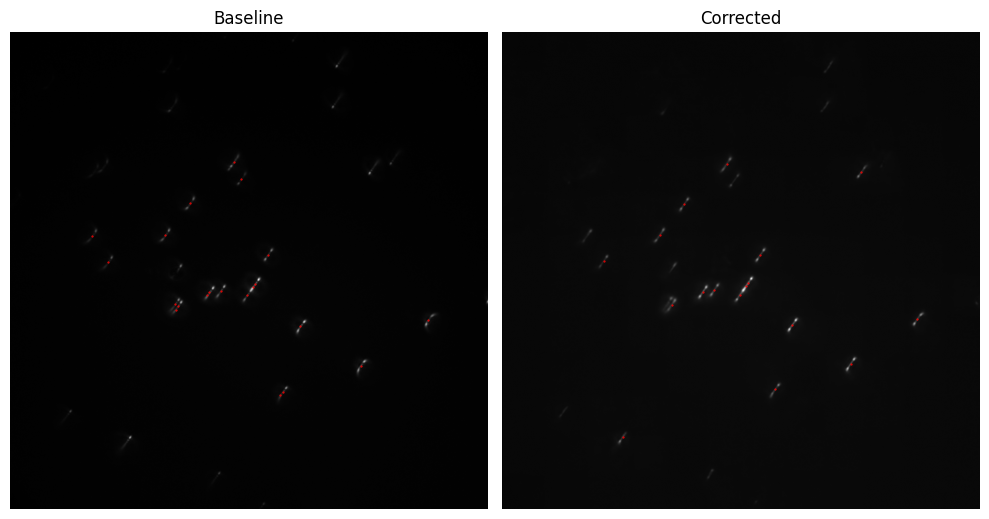

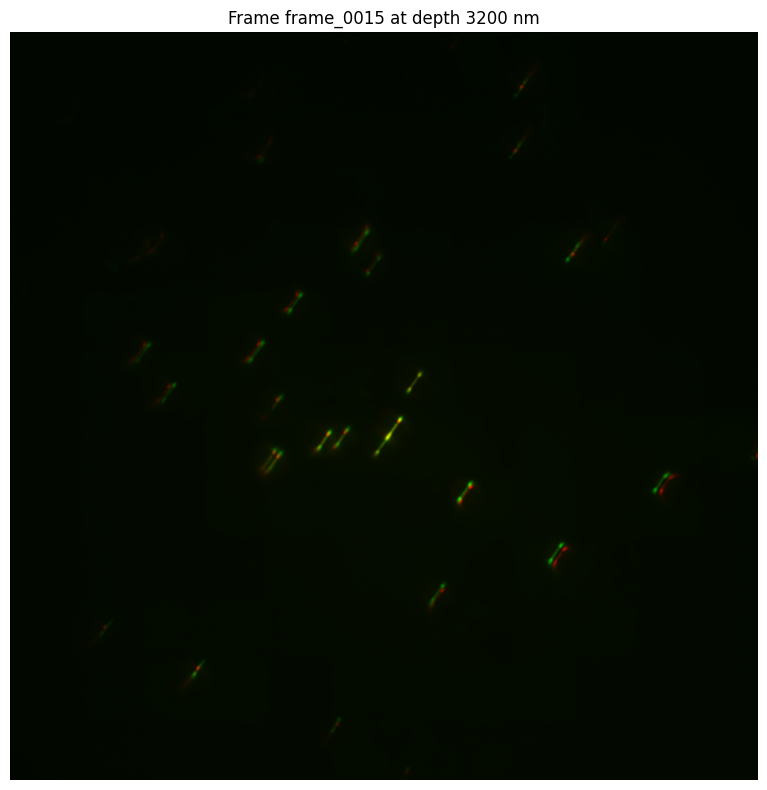

Matched pairs : 14
Mean lateral  : 456.22 nm
Mean depth    : 0.23 nm


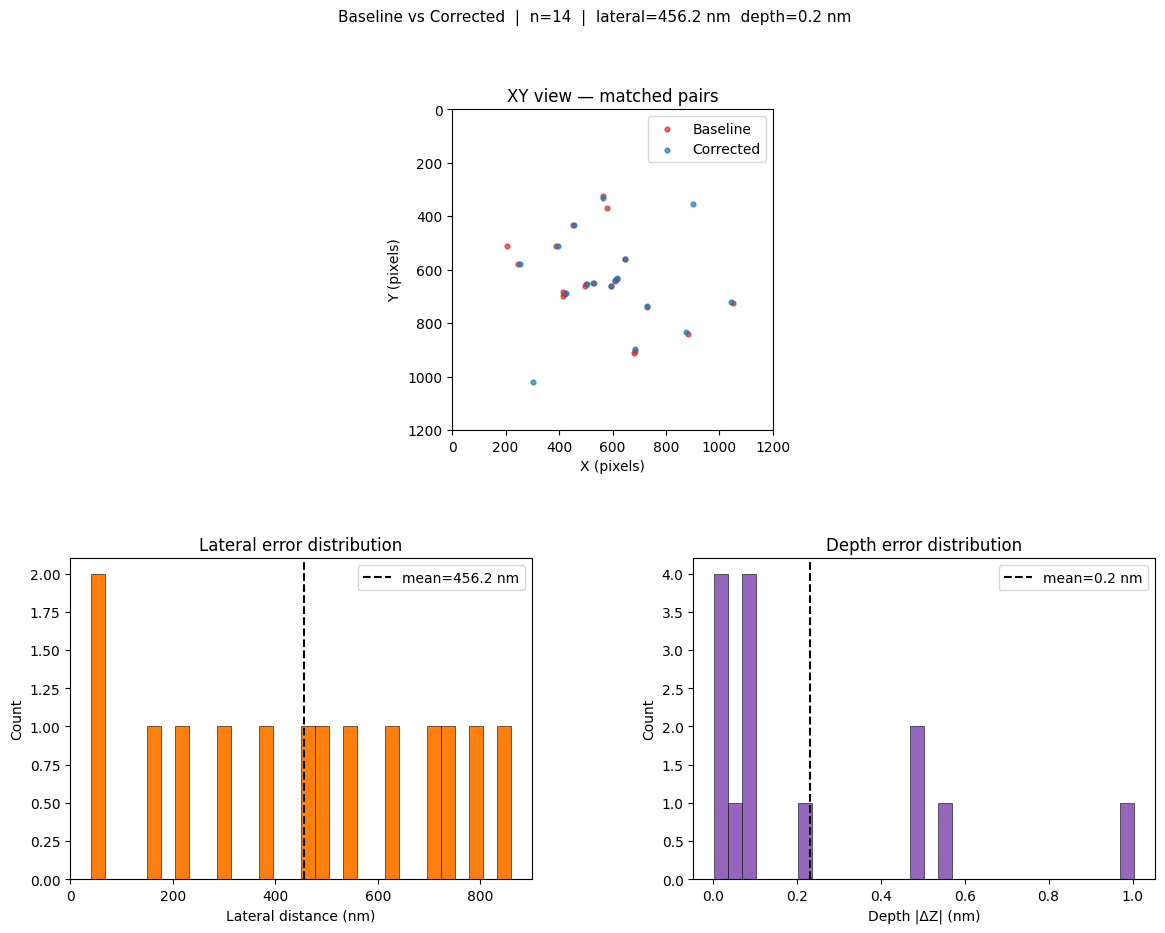

Processing frame frame_0020 at depth 2400 nm...


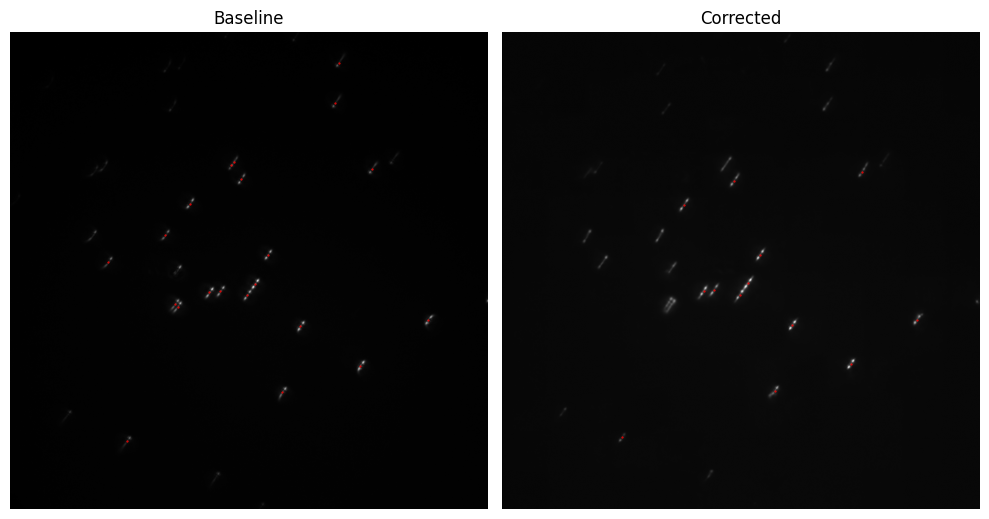

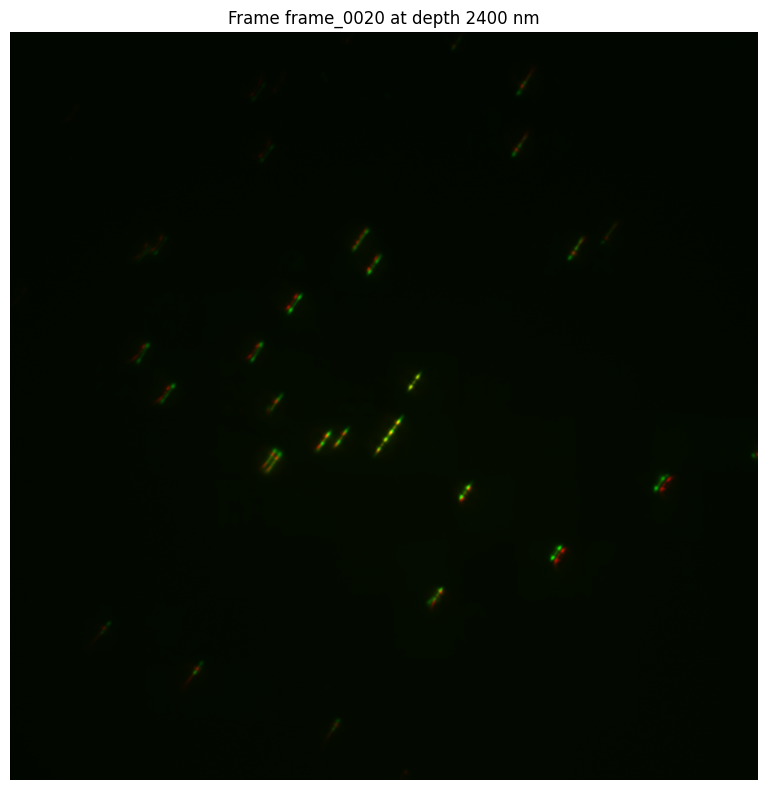

Matched pairs : 11
Mean lateral  : 471.01 nm
Mean depth    : 0.38 nm


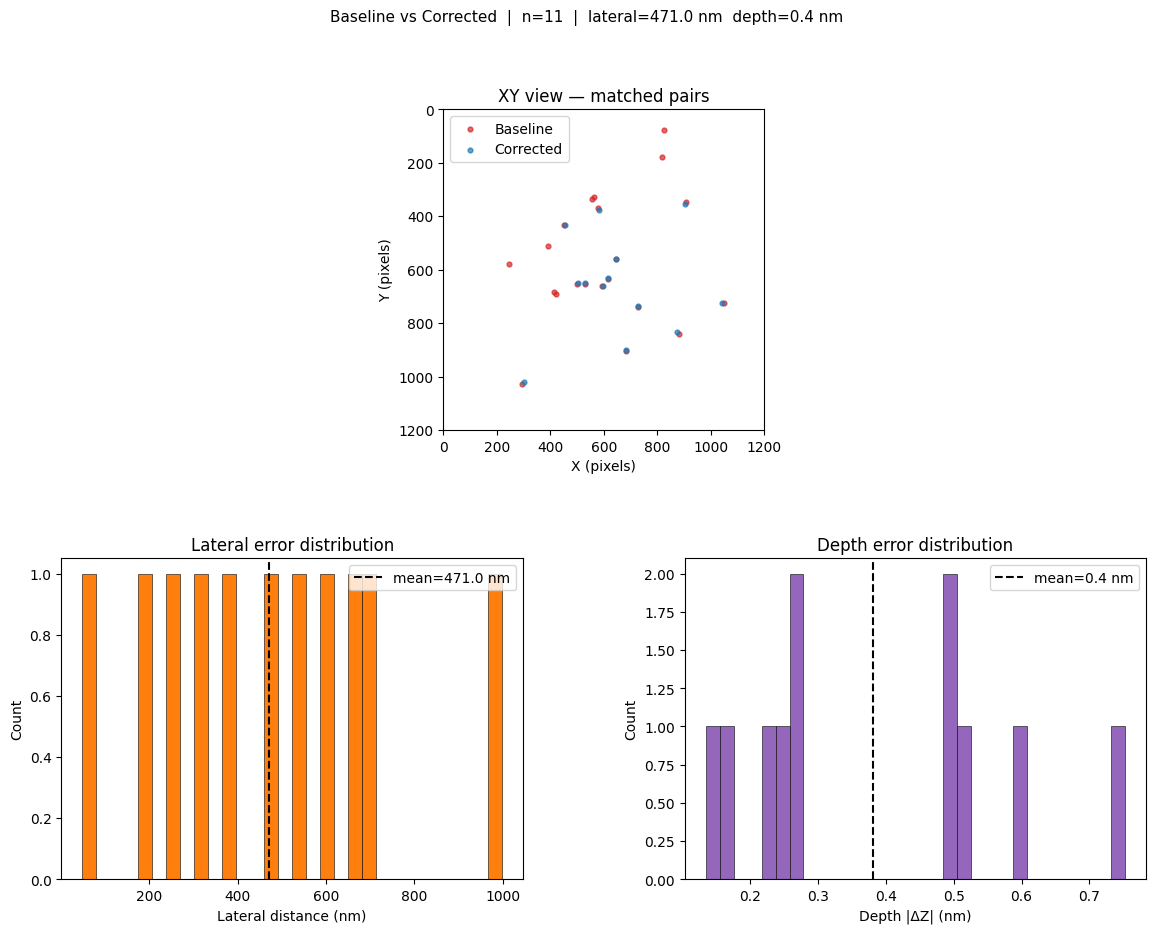

Processing frame frame_0025 at depth 1600 nm...


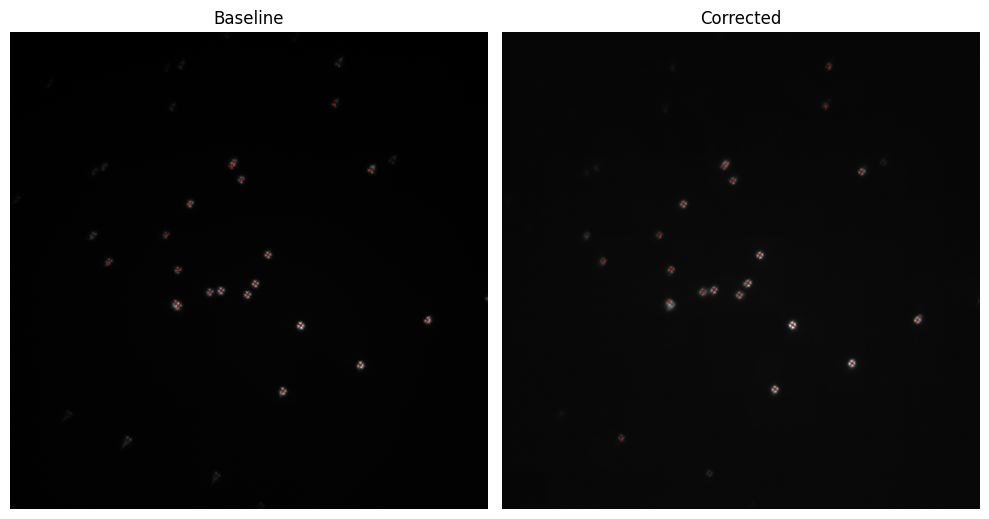

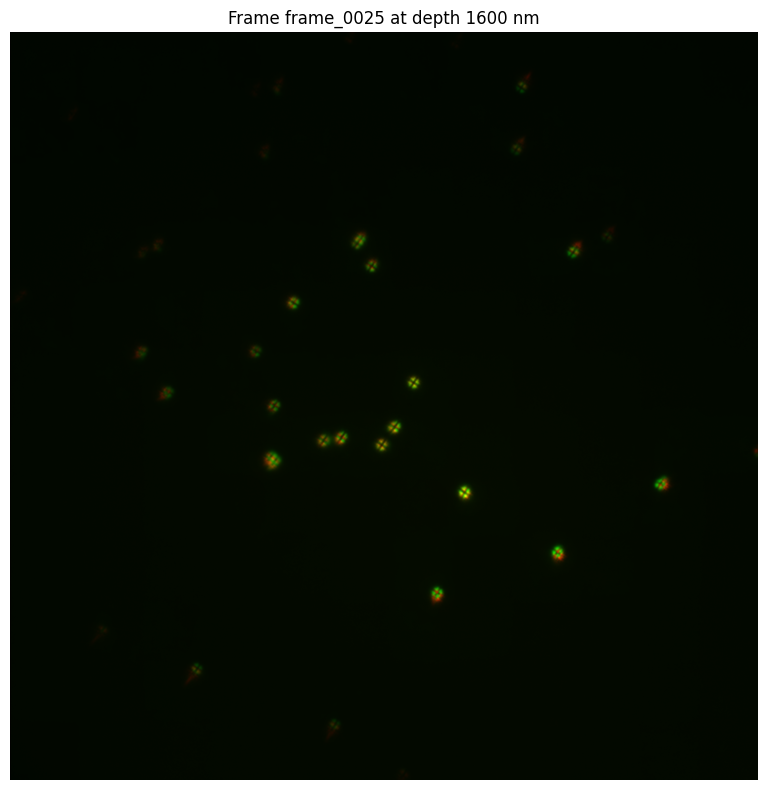

Matched pairs : 19
Mean lateral  : 391.78 nm
Mean depth    : 0.28 nm


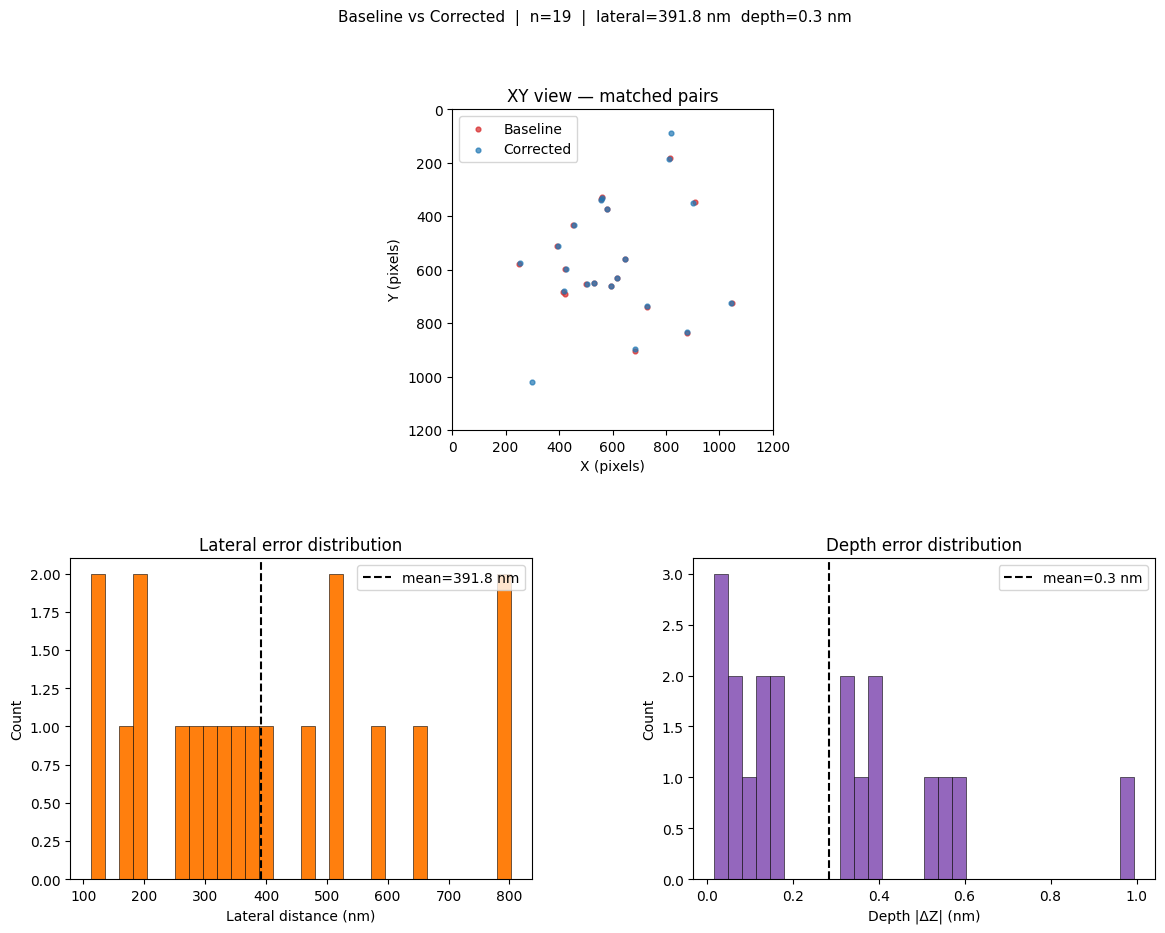

Processing frame frame_0030 at depth 800 nm...


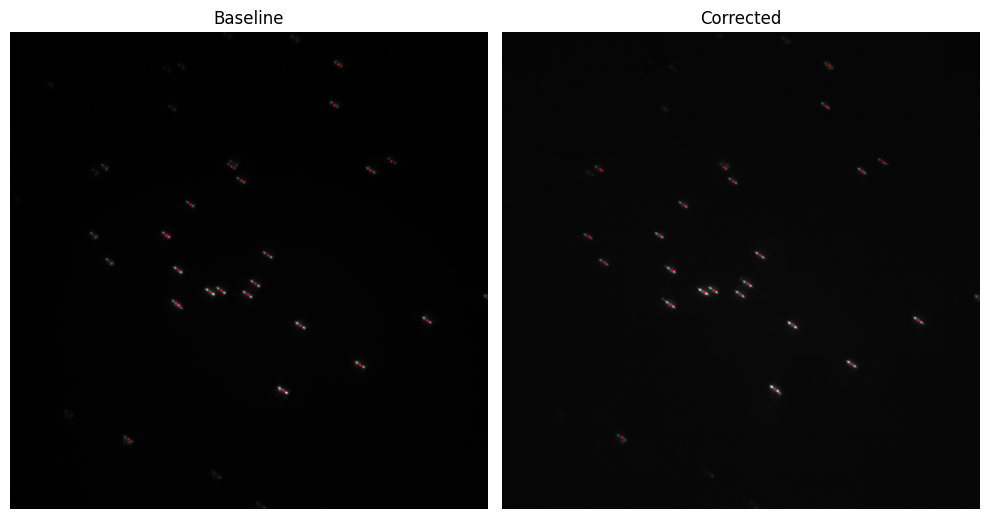

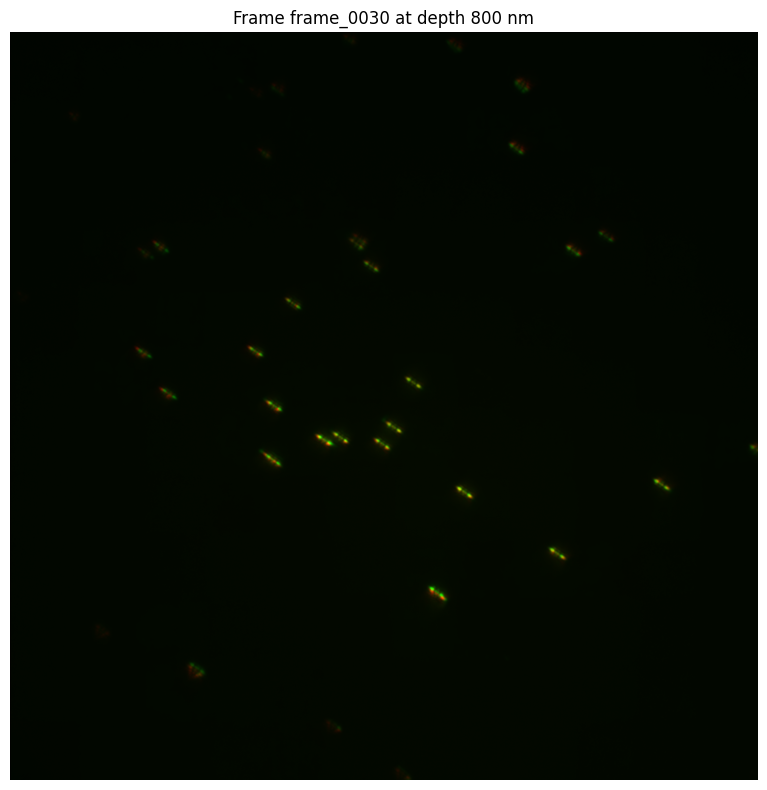

Matched pairs : 20
Mean lateral  : 258.98 nm
Mean depth    : 0.40 nm


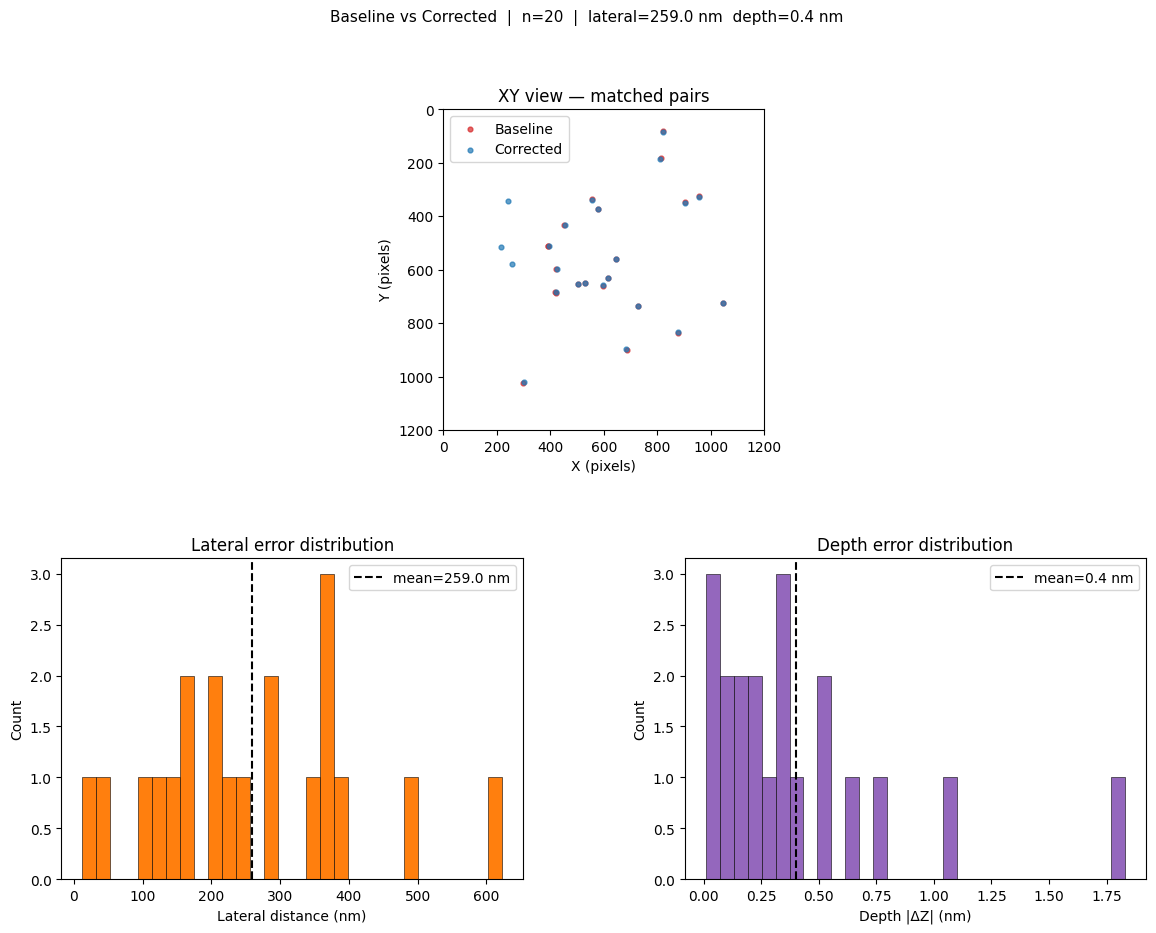

Processing frame frame_0035 at depth 0 nm...


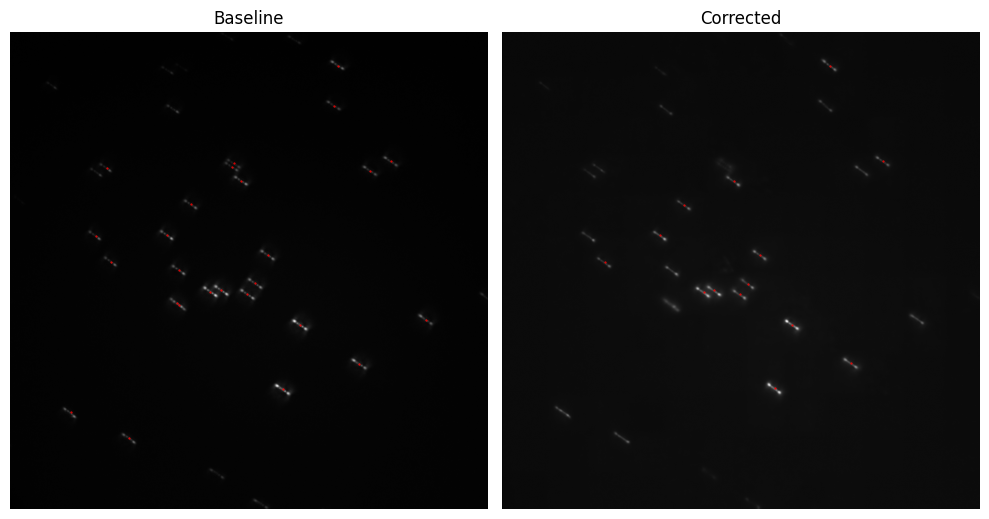

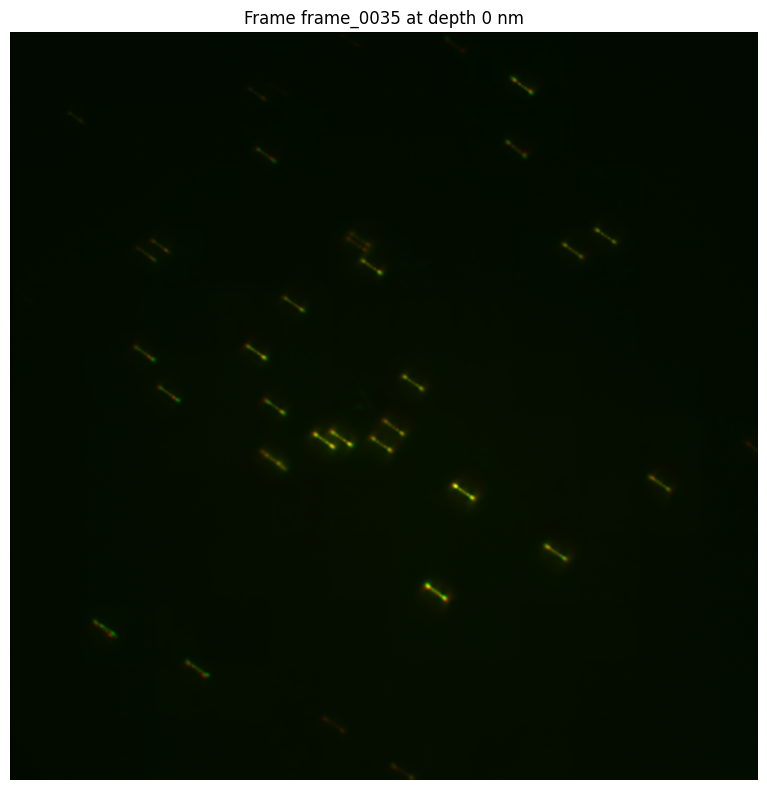

Matched pairs : 14
Mean lateral  : 169.55 nm
Mean depth    : 0.09 nm


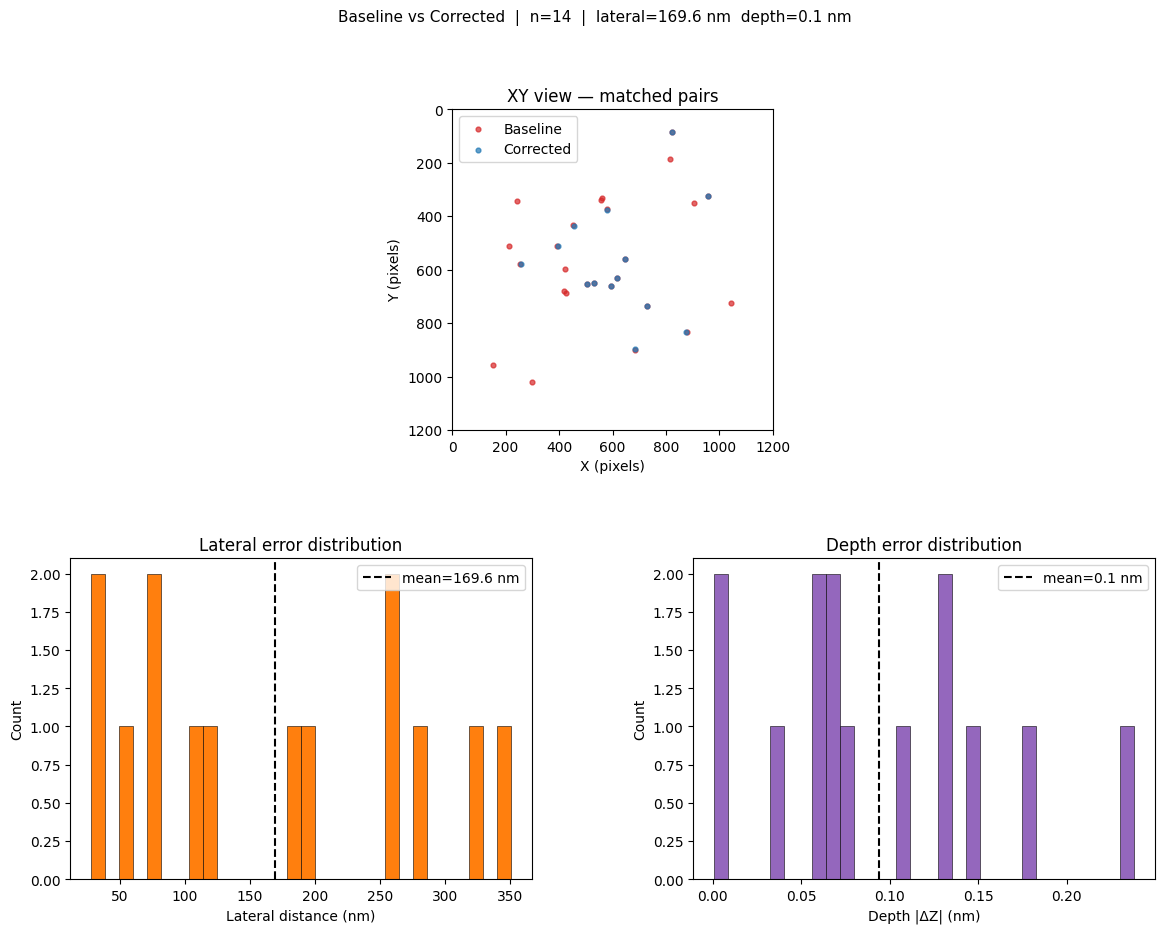

In [67]:
for frame_depth, frame in zip([3200, 2400,1600,800,0],['frame_0015', 'frame_0020', 'frame_0025', 'frame_0030', 'frame_0035']):
    print(f'Processing frame {frame} at depth {frame_depth} nm...')

    # original data
    frame_loc_csv_path = f"/home/omer/git/AutoDS3D/train_results/mse3/nfp_minus_3p5_z_0_to_3p2/photon_count_alignment/orig/{frame}.csv"
    image_path = f"/home/omer/experiments/mse3/BehindObj_001_range10_decomposedframes/{frame}.tif"

    im_baseline = tifffile.imread(image_path) 

    df_baseline = pd.read_csv(frame_loc_csv_path)
    df_filtered_baseline = df_baseline[(df_baseline['z [nm]']>=(frame_depth - localization_th))&(df_baseline['z [nm]']<=(frame_depth + localization_th))&(df_baseline['intensity [au]']>=param_dict['threshold'])]
    df_filtered_baseline.count()
    #clustered_df_baseline = select_strongest_localizations_by_radius(df_filtered_baseline, radius=1500)
    xyzps_baseline = df_filtered_baseline.to_numpy()[:, :4]

    # corrected data
    corrected_image_path = f"/home/omer/data/mse3/test_of_axis/nfp_minus3p5_z_0_to_3p2/beads_train_data_1200_by_1200/outputs/MSE3 SFEnet off-axis bead-robust retrain/2026-05-20_00-03-30/outputs/experiments/mse3/beads_tiled_1200/{frame}.tif"
    corrected_frame_loc_csv_path = f"/home/omer/git/AutoDS3D/train_results/mse3/nfp_minus_3p5_z_0_to_3p2/photon_count_alignment/doda/{frame}.csv"

    im_corrected = tifffile.imread(corrected_image_path)

    df = pd.read_csv(corrected_frame_loc_csv_path)
    df_filtered = df[(df['z [nm]']>=(frame_depth - localization_th))&(df['z [nm]']<=(frame_depth + localization_th))&(df['intensity [au]']>=param_dict['threshold'])]
    df_filtered.count()
    #clustered_df = select_strongest_localizations_by_radius(df_filtered, radius=1500)
    xyzps = df_filtered.to_numpy()[:, :4]

    bias_comparison(param_dict, xyzps_baseline, im_baseline, xyzps, im_corrected, device)
    rgb_overlay = overlay_images_rg(im_baseline, im_corrected, title=f'Frame {frame} at depth {frame_depth} nm')
    _, _, ps_xy = _compute_overlay(im_baseline, xyzps_baseline, param_dict)

    results = match_localizations_hungarian(
        xyzps_baseline,
        xyzps,
        label_a="Baseline",
        label_b="Corrected",
        max_distance=1000,
        pixel_size_nm=ps_xy * 1000,   # µm/pixel → nm/pixel, matches bias_comparison
    )


In [ ]:
im_corrected.shape

In [ ]:
# Release GPU memory
if 'model' in locals():
    del model
if 'volume2xyz' in locals():
    del volume2xyz
import gc
torch.cuda.empty_cache()
gc.collect()